# Visualización de Esquemas Unificados - Capa Silver

## Descripción

Este notebook visualiza los **esquemas unificados** generados para cada tipo de servicio del **NYC Taxi & Limousine Commission (TLC)**.

A partir de los archivos **JSON** producidos por el proceso de unificación de esquemas, se presenta la estructura final que será utilizada durante la transformación hacia la **capa Silver**, facilitando la validación de la estrategia de integración de datos.

---

## Objetivos

- Visualizar la estructura del esquema unificado para cada tipo de servicio.
- Comparar las columnas existentes entre los distintos datasets.
- Identificar atributos comunes y específicos de cada esquema.
- Validar la consistencia de la estrategia de unificación antes del procesamiento.

---

## Fuente de datos

| Elemento | Descripción |
|----------|-------------|
| **Origen** | Esquemas unificados generados por `generate_unified_schema.py`. |
| **Ubicación** | `data/silver/unified_schema/_schemas/` |
| **Datasets** | Yellow Taxi, Green Taxi, FHV y FHVHV. |


---

> **Resultado esperado:** Validar que los esquemas unificados representen correctamente la estructura final de cada tipo de servicio y sirvan como base para las transformaciones de la **capa Silver**.

In [2]:
import os
import json
from pathlib import Path
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Colores institucionales
COLORS = {
    'yellow': '#F4D03F',
    'green': '#58D68D',
    'fhv': '#5DADE2',
    'fhvhv': '#E74C3C',
    'primary': '#2E86AB',
    'success': '#27AE60',
    'warning': '#F39C12',
    'danger': '#E74C3C',
    'excluded': '#95A5A6'
}

# ============================================================
# CONFIGURACIÓN DE RUTAS
# ============================================================

def get_project_root():
    current = Path.cwd()
    while current != current.parent:
        if (current / "data" / "bronze").exists():
            return current
        current = current.parent
    return Path.cwd()

ROOT_DIR = get_project_root()
SCHEMAS_DIR = ROOT_DIR / "data" / "silver" / "unified_schema" / "_schemas"

print("=" * 80)
print(" VISUALIZACIÓN - ESQUEMAS UNIFICADOS")
print("=" * 80)
print(f" Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f" Esquemas: {SCHEMAS_DIR}")

if not SCHEMAS_DIR.exists():
    print("\n❌ ERROR: No se encontraron esquemas.")
    print("   Ejecuta primero: 03_generate_unified_schema.py")
    exit()

 VISUALIZACIÓN - ESQUEMAS UNIFICADOS
 Fecha: 2026-07-17 01:29:23
 Esquemas: c:\Users\Jean Carlos\OneDrive\Desktop\BIG DATA FINAL\Final-Gesti-n_De_Datos_Masivos\data\silver\unified_schema\_schemas


In [4]:
# ============================================================
# CARGA DE ESQUEMAS
# ============================================================

TAXI_TYPES = ['yellow', 'green', 'fhv', 'fhvhv']
EXCLUDED_TYPES = ['fhvhv']

def load_schema(taxi_type):
    """Carga un esquema unificado"""
    path = SCHEMAS_DIR / f"{taxi_type}_unified_schema.json"
    if not path.exists():
        return None
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

def load_all_schemas():
    """Carga todos los esquemas disponibles"""
    schemas = {}
    for taxi_type in TAXI_TYPES:
        schema = load_schema(taxi_type)
        if schema:
            schemas[taxi_type] = schema
    return schemas

print(" Cargando esquemas...")
ALL_SCHEMAS = load_all_schemas()

print(f" Esquemas cargados: {len(ALL_SCHEMAS)}")

print("\n Disponibilidad de esquemas:")
for taxi_type in TAXI_TYPES:
    if taxi_type in ALL_SCHEMAS:
        cols = len(ALL_SCHEMAS[taxi_type])
        excluded = " (EXCLUIDO)" if taxi_type in EXCLUDED_TYPES else ""
        print(f"   ✅ {taxi_type.upper()}{excluded}: {cols} columnas")
    else:
        print(f"   ❌ {taxi_type.upper()}: No disponible")

 Cargando esquemas...
 Esquemas cargados: 4

 Disponibilidad de esquemas:
   ✅ YELLOW: 21 columnas
   ✅ GREEN: 21 columnas
   ✅ FHV: 6 columnas
   ✅ FHVHV (EXCLUIDO): 25 columnas


 1. RESUMEN GENERAL DE ESQUEMAS UNIFICADOS

 Tabla Resumen:
  Tipo  Columnas  String  Numeric  Timestamp    Estado
YELLOW        21       4       15          2    ACTIVO
 GREEN        21       2       17          2    ACTIVO
   FHV         6       1        3          2    ACTIVO
 FHVHV        25       9       12          4  EXCLUIDO


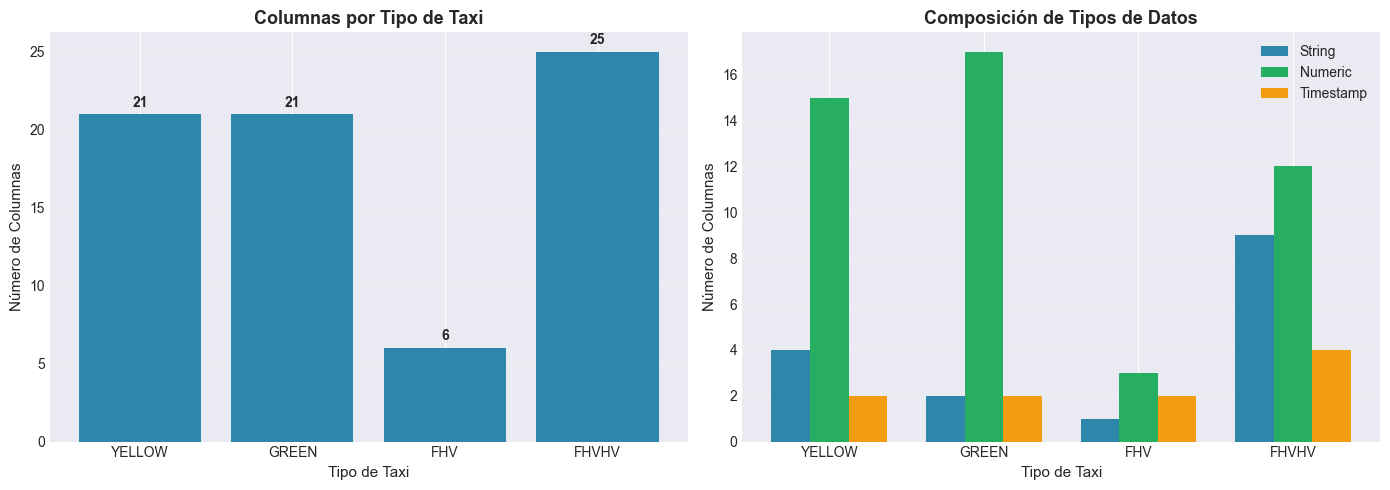


💡 CONCLUSIONES:
   📌 YELLOW: 21 columnas (4 string, 15 numeric, 2 timestamp)
   📌 GREEN: 21 columnas (2 string, 17 numeric, 2 timestamp)
   📌 FHV: 6 columnas (1 string, 3 numeric, 2 timestamp)
   📌 FHVHV: 25 columnas (9 string, 12 numeric, 4 timestamp)


In [6]:
# ============================================================
# 1. RESUMEN GENERAL DE ESQUEMAS
# ============================================================

print("=" * 80)
print(" 1. RESUMEN GENERAL DE ESQUEMAS UNIFICADOS")
print("=" * 80)

summary_data = []
for taxi_type, schema in ALL_SCHEMAS.items():
    columns = list(schema.keys())
    types = list(schema.values())
    
    # Contar tipos de datos
    type_counts = pd.Series(types).value_counts().to_dict()
    
    # Identificar columnas con tipos específicos
    string_cols = [c for c, t in schema.items() if 'string' in t.lower()]
    numeric_cols = [c for c, t in schema.items() if 'int' in t.lower() or 'double' in t.lower() or 'float' in t.lower()]
    timestamp_cols = [c for c, t in schema.items() if 'timestamp' in t.lower()]
    
    is_excluded = taxi_type in EXCLUDED_TYPES
    summary_data.append({
        'Tipo': taxi_type.upper(),
        'Columnas': len(columns),
        'String': len(string_cols),
        'Numeric': len(numeric_cols),
        'Timestamp': len(timestamp_cols),
        'Estado': ' EXCLUIDO' if is_excluded else ' ACTIVO'
    })

df_summary = pd.DataFrame(summary_data)

print("\n Tabla Resumen:")
print(df_summary.to_string(index=False))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Número de columnas
ax1 = axes[0]
colors = [COLORS['excluded'] if row['Estado'] == '🚫 EXCLUIDO' else COLORS['primary'] 
          for _, row in df_summary.iterrows()]
bars = ax1.bar(df_summary['Tipo'], df_summary['Columnas'], color=colors)
ax1.set_title('Columnas por Tipo de Taxi', fontsize=13, fontweight='bold')
ax1.set_xlabel('Tipo de Taxi', fontsize=11)
ax1.set_ylabel('Número de Columnas', fontsize=11)
ax1.grid(axis='y', alpha=0.25)

for bar, val in zip(bars, df_summary['Columnas']):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{int(val)}', ha='center', va='bottom', fontweight='bold')

# Gráfico 2: Composición de tipos de datos
ax2 = axes[1]
x = np.arange(len(df_summary['Tipo']))
width = 0.25

bars1 = ax2.bar(x - width, df_summary['String'], width, label='String', color=COLORS['primary'])
bars2 = ax2.bar(x, df_summary['Numeric'], width, label='Numeric', color=COLORS['success'])
bars3 = ax2.bar(x + width, df_summary['Timestamp'], width, label='Timestamp', color=COLORS['warning'])

ax2.set_title('Composición de Tipos de Datos', fontsize=13, fontweight='bold')
ax2.set_xlabel('Tipo de Taxi', fontsize=11)
ax2.set_ylabel('Número de Columnas', fontsize=11)
ax2.set_xticks(x)
ax2.set_xticklabels(df_summary['Tipo'])
ax2.legend()
ax2.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

print("\n💡 CONCLUSIONES:")
for _, row in df_summary.iterrows():
    if row['Estado'] == '🚫 EXCLUIDO':
        print(f"   🚫 {row['Tipo']}: Excluido del pipeline")
    else:
        print(f"   📌 {row['Tipo']}: {row['Columnas']} columnas ({row['String']} string, {row['Numeric']} numeric, {row['Timestamp']} timestamp)")

 2. COMPARATIVA DE COLUMNAS ENTRE TIPOS DE TAXI

 Columnas comunes a todos los tipos (2):
   DOLocationID, PULocationID

 Columnas únicas por tipo:
   • YELLOW: 4 columnas únicas
     Airport_fee, airport_fee, tpep_dropoff_datetime, tpep_pickup_datetime
   • GREEN: 4 columnas únicas
     ehail_fee, lpep_dropoff_datetime, lpep_pickup_datetime, trip_type
   • FHV: 4 columnas únicas
     Affiliated_base_number, SR_Flag, dropoff_datetime, pickup_datetime


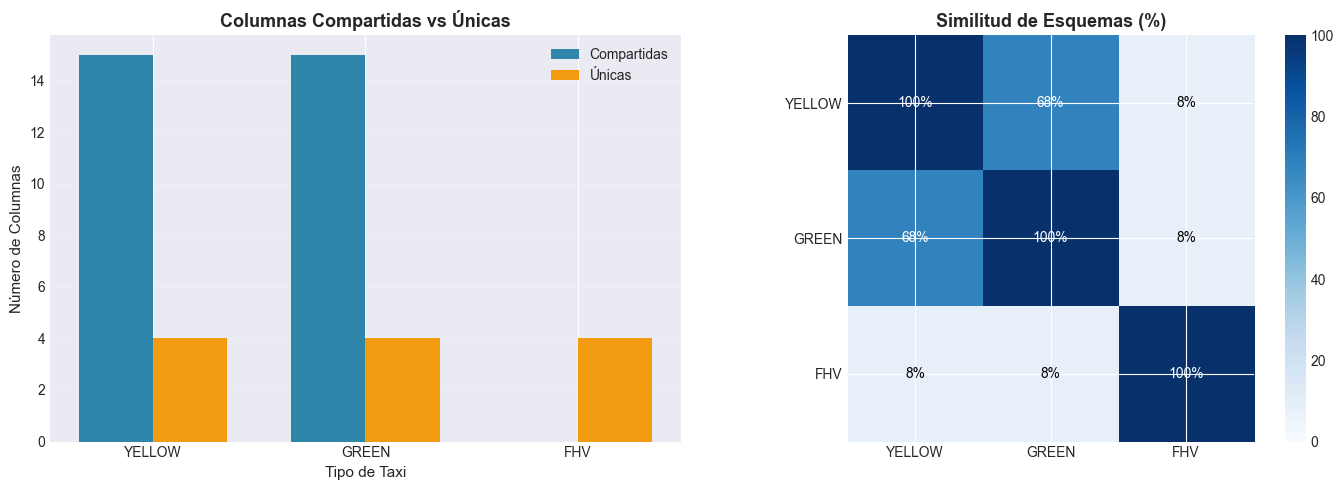

In [10]:
# ============================================================
# 2. COMPARATIVA DE COLUMNAS ENTRE TIPOS
# ============================================================

print("=" * 80)
print(" 2. COMPARATIVA DE COLUMNAS ENTRE TIPOS DE TAXI")
print("=" * 80)

# Solo tipos activos (excluir fhvhv)
active_schemas = {k: v for k, v in ALL_SCHEMAS.items() if k not in EXCLUDED_TYPES}

if len(active_schemas) >= 2:
    # Encontrar columnas comunes y únicas
    all_columns = {}
    for taxi_type, schema in active_schemas.items():
        for col in schema.keys():
            if col not in all_columns:
                all_columns[col] = []
            all_columns[col].append(taxi_type)
    
    # Clasificar columnas
    common_cols = [col for col, types in all_columns.items() if len(types) == len(active_schemas)]
    unique_cols = {taxi_type: [] for taxi_type in active_schemas.keys()}
    shared_cols = {taxi_type: [] for taxi_type in active_schemas.keys()}
    
    for col, types in all_columns.items():
        if col in common_cols:
            continue
        for taxi_type in types:
            if len(types) == 1:
                unique_cols[taxi_type].append(col)
            else:
                shared_cols[taxi_type].append(col)
    
    # Mostrar resultados
    print(f"\n Columnas comunes a todos los tipos ({len(common_cols)}):")
    if common_cols:
        print(f"   {', '.join(common_cols[:10])}")
        if len(common_cols) > 10:
            print(f"   ... y {len(common_cols) - 10} columnas más")
    else:
        print("   No hay columnas comunes entre todos los tipos")
    
    print(f"\n Columnas únicas por tipo:")
    for taxi_type, cols in unique_cols.items():
        if cols:
            print(f"   • {taxi_type.upper()}: {len(cols)} columnas únicas")
            print(f"     {', '.join(cols[:5])}")
            if len(cols) > 5:
                print(f"     ... y {len(cols) - 5} columnas más")
        else:
            print(f"   • {taxi_type.upper()}: Sin columnas únicas")
    
    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gráfico 1: Columnas comunes vs únicas
    ax1 = axes[0]
    x = np.arange(len(active_schemas))
    width = 0.35
    
    unique_counts = [len(unique_cols[t]) for t in active_schemas.keys()]
    shared_counts = [len(shared_cols[t]) for t in active_schemas.keys()]
    
    bars1 = ax1.bar(x - width/2, shared_counts, width, label='Compartidas', color=COLORS['primary'])
    bars2 = ax1.bar(x + width/2, unique_counts, width, label='Únicas', color=COLORS['warning'])
    
    ax1.set_title('Columnas Compartidas vs Únicas', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Tipo de Taxi', fontsize=11)
    ax1.set_ylabel('Número de Columnas', fontsize=11)
    ax1.set_xticks(x)
    ax1.set_xticklabels([t.upper() for t in active_schemas.keys()])
    ax1.legend()
    ax1.grid(axis='y', alpha=0.25)
    
    # Gráfico 2: Matriz de overlap (Venn)
    ax2 = axes[1]
    
    # Crear matriz de similitud
    tipos = list(active_schemas.keys())
    n = len(tipos)
    similarity_matrix = np.zeros((n, n))
    
    for i, t1 in enumerate(tipos):
        for j, t2 in enumerate(tipos):
            cols1 = set(active_schemas[t1].keys())
            cols2 = set(active_schemas[t2].keys())
            similarity_matrix[i, j] = len(cols1 & cols2) / len(cols1 | cols2) * 100
    
    im = ax2.imshow(similarity_matrix, cmap='Blues', vmin=0, vmax=100)
    ax2.set_xticks(range(n))
    ax2.set_yticks(range(n))
    ax2.set_xticklabels([t.upper() for t in tipos])
    ax2.set_yticklabels([t.upper() for t in tipos])
    ax2.set_title('Similitud de Esquemas (%)', fontsize=13, fontweight='bold')
    
    # Añadir valores
    for i in range(n):
        for j in range(n):
            ax2.text(j, i, f'{similarity_matrix[i, j]:.0f}%',
                    ha='center', va='center', fontsize=10,
                    color='white' if similarity_matrix[i, j] > 50 else 'black')
    
    plt.colorbar(im, ax=ax2)
    plt.tight_layout()
    plt.show()
    
else:
    print("⚠️ No hay suficientes tipos activos para comparar")

 3. DETALLE DE ESQUEMA POR TIPO DE TAXI

 YELLOW
   Total columnas: 21

   Distribución de tipos:
      double: 9 columnas
      int: 6 columnas
      string: 4 columnas
      timestamp: 2 columnas

   Columnas String:
      Airport_fee, airport_fee, cbd_congestion_fee, store_and_fwd_flag

   Columnas Numéricas:
      DOLocationID, PULocationID, RatecodeID, VendorID, congestion_surcharge, extra, fare_amount, improvement_surcharge, mta_tax, passenger_count ... y 5 más

   Columnas Timestamp:
      tpep_dropoff_datetime, tpep_pickup_datetime


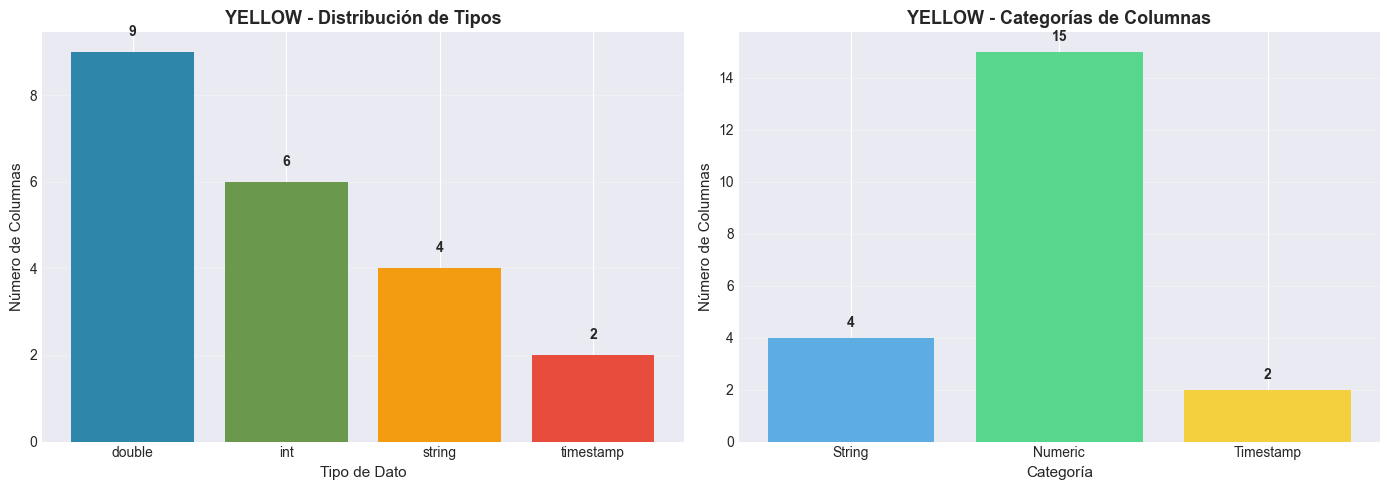


 GREEN
   Total columnas: 21

   Distribución de tipos:
      double: 10 columnas
      int: 7 columnas
      string: 2 columnas
      timestamp: 2 columnas

   Columnas String:
      cbd_congestion_fee, store_and_fwd_flag

   Columnas Numéricas:
      DOLocationID, PULocationID, RatecodeID, VendorID, congestion_surcharge, ehail_fee, extra, fare_amount, improvement_surcharge, mta_tax ... y 7 más

   Columnas Timestamp:
      lpep_dropoff_datetime, lpep_pickup_datetime


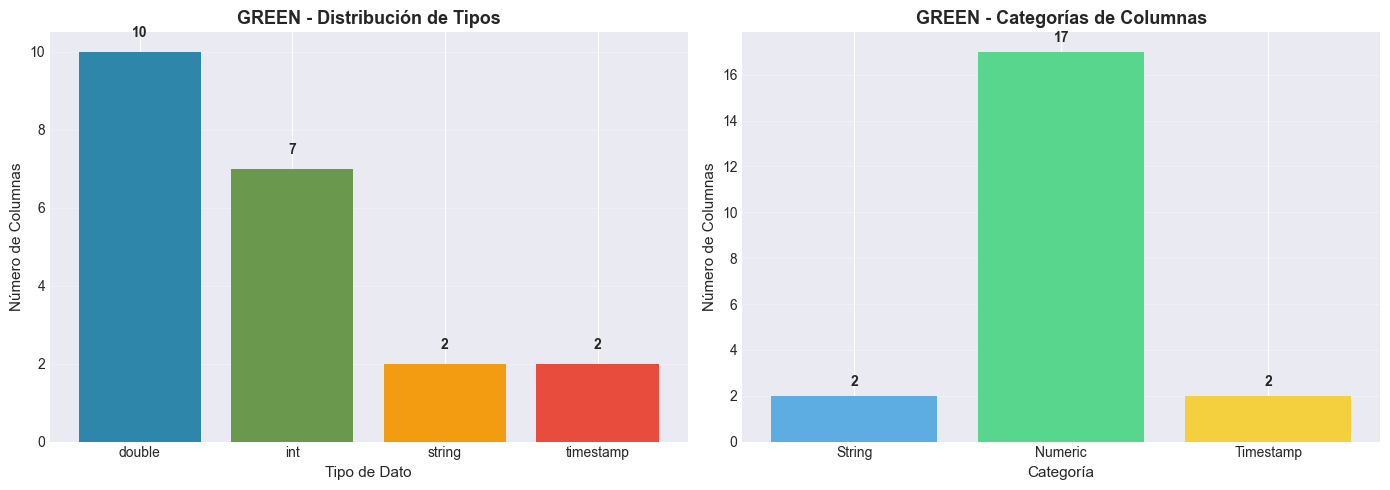


 FHV
   Total columnas: 6

   Distribución de tipos:
      int: 3 columnas
      timestamp: 2 columnas
      string: 1 columnas

   Columnas String:
      Affiliated_base_number

   Columnas Numéricas:
      DOLocationID, PULocationID, SR_Flag

   Columnas Timestamp:
      dropoff_datetime, pickup_datetime


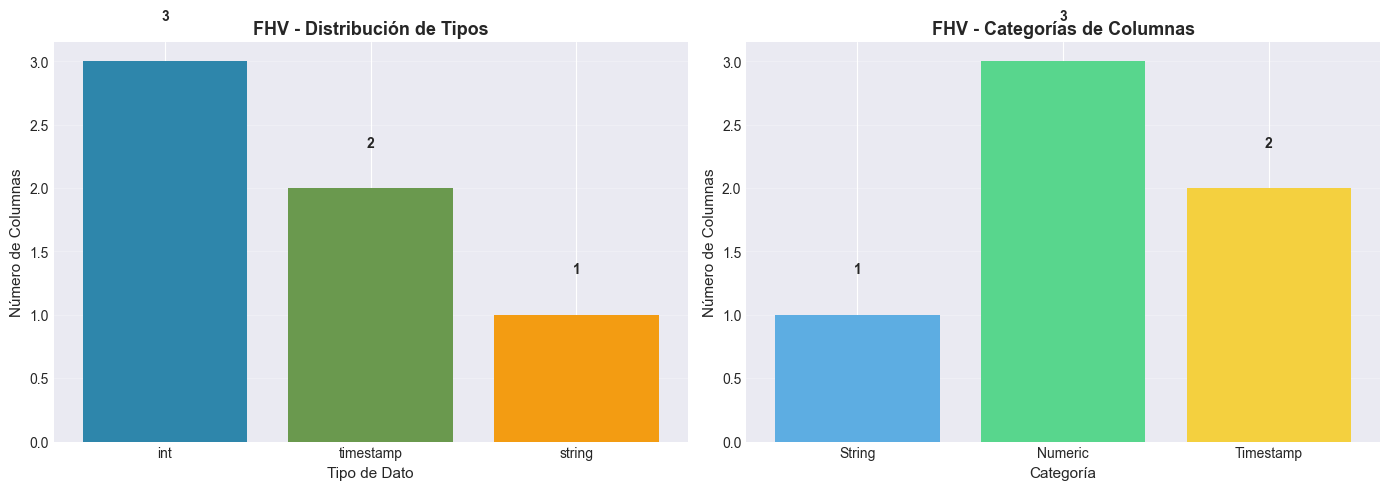


 FHVHV (EXCLUIDO)
   Total columnas: 25

   Distribución de tipos:
      string: 9 columnas
      double: 9 columnas
      timestamp: 4 columnas
      int: 3 columnas

   Columnas String:
      access_a_ride_flag, cbd_congestion_fee, dispatching_base_num, hvfhs_license_num, originating_base_num, shared_match_flag, shared_request_flag, wav_match_flag, wav_request_flag

   Columnas Numéricas:
      DOLocationID, PULocationID, airport_fee, base_passenger_fare, bcf, congestion_surcharge, driver_pay, sales_tax, tips, tolls ... y 2 más

   Columnas Timestamp:
      dropoff_datetime, on_scene_datetime, pickup_datetime, request_datetime


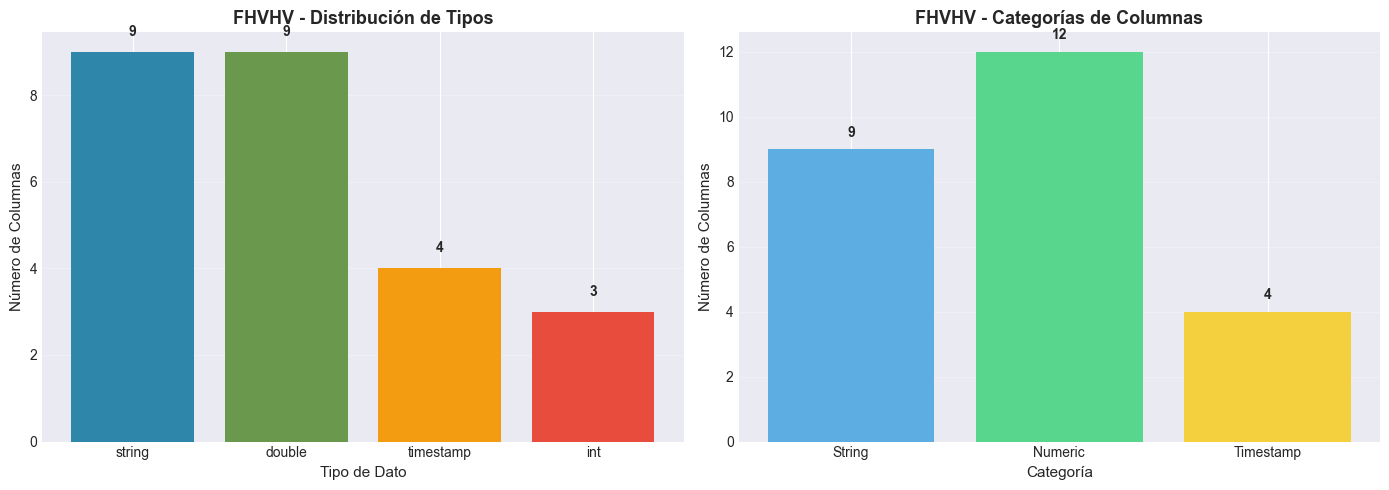

In [12]:
# ============================================================
# 3. DETALLE DE ESQUEMA POR TIPO
# ============================================================

print("=" * 80)
print(" 3. DETALLE DE ESQUEMA POR TIPO DE TAXI")
print("=" * 80)

for taxi_type, schema in ALL_SCHEMAS.items():
    is_excluded = taxi_type in EXCLUDED_TYPES
    
    print(f"\n{'='*70}")
    print(f" {taxi_type.upper()}" + (" (EXCLUIDO)" if is_excluded else ""))
    print(f"{'='*70}")
    print(f"   Total columnas: {len(schema)}")
    
    # Crear DataFrame del esquema
    df_schema = pd.DataFrame(list(schema.items()), columns=['Columna', 'Tipo'])
    
    # Mostrar estadísticas de tipos
    type_counts = df_schema['Tipo'].value_counts()
    print("\n   Distribución de tipos:")
    for dtype, count in type_counts.items():
        print(f"      {dtype}: {count} columnas")
    
    # Mostrar columnas por categoría
    string_cols = df_schema[df_schema['Tipo'].str.contains('string', case=False)]['Columna'].tolist()
    numeric_cols = df_schema[df_schema['Tipo'].str.contains('int|double|float|decimal', case=False)]['Columna'].tolist()
    timestamp_cols = df_schema[df_schema['Tipo'].str.contains('timestamp', case=False)]['Columna'].tolist()
    
    print("\n   Columnas String:")
    print(f"      {', '.join(string_cols[:10])}" + (f" ... y {len(string_cols)-10} más" if len(string_cols) > 10 else ""))
    
    print("\n   Columnas Numéricas:")
    print(f"      {', '.join(numeric_cols[:10])}" + (f" ... y {len(numeric_cols)-10} más" if len(numeric_cols) > 10 else ""))
    
    print("\n   Columnas Timestamp:")
    print(f"      {', '.join(timestamp_cols[:5])}" + (f" ... y {len(timestamp_cols)-5} más" if len(timestamp_cols) > 5 else ""))
    
    # Visualización del esquema
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gráfico 1: Distribución de tipos
    ax1 = axes[0]
    colors = ['#2E86AB', '#6A994E', '#F39C12', '#E74C3C', '#95A5A6'][:len(type_counts)]
    bars = ax1.bar(type_counts.index, type_counts.values, color=colors)
    ax1.set_title(f'{taxi_type.upper()} - Distribución de Tipos', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Tipo de Dato', fontsize=11)
    ax1.set_ylabel('Número de Columnas', fontsize=11)
    ax1.grid(axis='y', alpha=0.25)
    
    for bar, val in zip(bars, type_counts.values):
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{int(val)}', ha='center', va='bottom', fontweight='bold')
    
    # Gráfico 2: Columnas por categoría
    ax2 = axes[1]
    categories = ['String', 'Numeric', 'Timestamp']
    counts = [len(string_cols), len(numeric_cols), len(timestamp_cols)]
    colors2 = ['#5DADE2', '#58D68D', '#F4D03F']
    bars = ax2.bar(categories, counts, color=colors2)
    ax2.set_title(f'{taxi_type.upper()} - Categorías de Columnas', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Categoría', fontsize=11)
    ax2.set_ylabel('Número de Columnas', fontsize=11)
    ax2.grid(axis='y', alpha=0.25)
    
    for bar, val in zip(bars, counts):
        ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{int(val)}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

 4. COLUMNAS PARA ESQUEMA UNIFICADO FINAL

 Columnas que aparecen en TODOS los tipos activos (2):
   • DOLocationID
   • PULocationID

 Columnas que aparecen en ALGUNOS tipos (27):
   • Affiliated_base_number: FHV
   • Airport_fee: YELLOW
   • RatecodeID: YELLOW, GREEN
   • SR_Flag: FHV
   • VendorID: YELLOW, GREEN
   • airport_fee: YELLOW
   • cbd_congestion_fee: YELLOW, GREEN
   • congestion_surcharge: YELLOW, GREEN
   • dropoff_datetime: FHV
   • ehail_fee: GREEN
   • extra: YELLOW, GREEN
   • fare_amount: YELLOW, GREEN
   • improvement_surcharge: YELLOW, GREEN
   • lpep_dropoff_datetime: GREEN
   • lpep_pickup_datetime: GREEN
   • mta_tax: YELLOW, GREEN
   • passenger_count: YELLOW, GREEN
   • payment_type: YELLOW, GREEN
   • pickup_datetime: FHV
   • store_and_fwd_flag: YELLOW, GREEN
   • tip_amount: YELLOW, GREEN
   • tolls_amount: YELLOW, GREEN
   • total_amount: YELLOW, GREEN
   • tpep_dropoff_datetime: YELLOW
   • tpep_pickup_datetime: YELLOW
   • trip_distance: YELLOW, GREEN


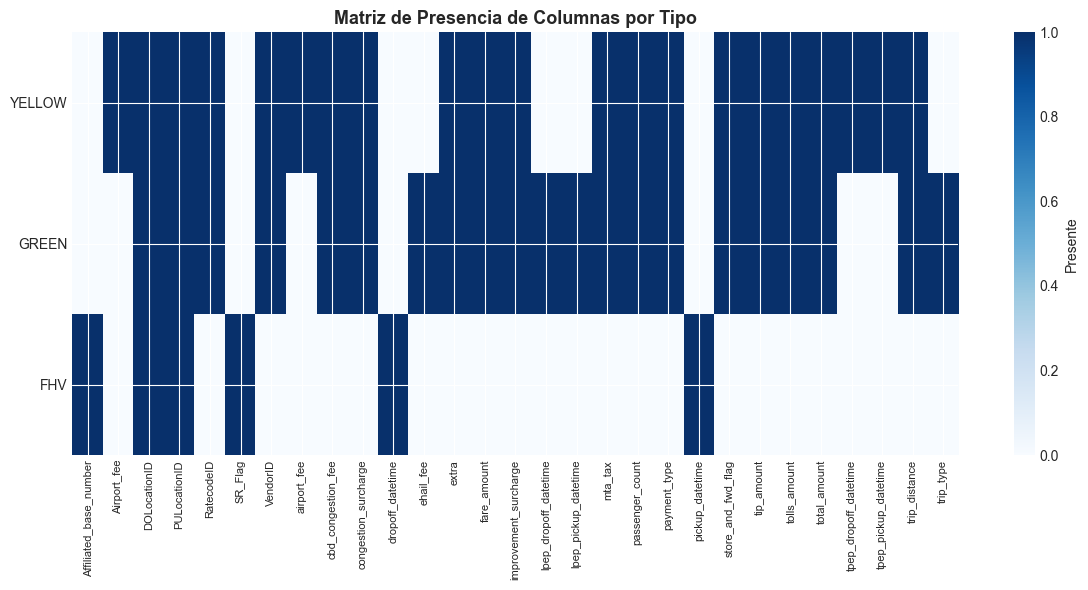


💡 RECOMENDACIONES PARA UNIFICACIÓN FINAL:
    2 columnas comunes → Se pueden unificar directamente
    27 columnas parciales → Requieren manejo especial
      • 12 columnas únicas de un solo tipo


In [16]:
# ============================================================
# 4. COLUMNAS PARA ESQUEMA UNIFICADO FINAL
# ============================================================

print("=" * 80)
print(" 4. COLUMNAS PARA ESQUEMA UNIFICADO FINAL")
print("=" * 80)

# Solo tipos activos
active_schemas = {k: v for k, v in ALL_SCHEMAS.items() if k not in EXCLUDED_TYPES}

if active_schemas:
    # Encontrar todas las columnas que aparecen en al menos un tipo
    all_columns_set = set()
    for schema in active_schemas.values():
        all_columns_set.update(schema.keys())
    
    # Identificar columnas que aparecen en todos los tipos activos
    common_cols = []
    for col in all_columns_set:
        appears_in_all = all(col in active_schemas[t] for t in active_schemas.keys())
        if appears_in_all:
            common_cols.append(col)
    
    # Identificar columnas que aparecen en algunos tipos
    partial_cols = {}
    for col in all_columns_set:
        if col not in common_cols:
            appears_in = [t.upper() for t in active_schemas.keys() if col in active_schemas[t]]
            if appears_in:
                partial_cols[col] = appears_in
    
    print(f"\n Columnas que aparecen en TODOS los tipos activos ({len(common_cols)}):")
    if common_cols:
        for col in sorted(common_cols):
            print(f"   • {col}")
    else:
        print("   No hay columnas comunes entre todos los tipos")
    
    print(f"\n Columnas que aparecen en ALGUNOS tipos ({len(partial_cols)}):")
    if partial_cols:
        for col, appears_in in sorted(partial_cols.items()):
            print(f"   • {col}: {', '.join(appears_in)}")
    
    # Visualización
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Preparar datos para heatmap
    tipos = list(active_schemas.keys())
    cols_list = sorted(all_columns_set)
    
    matrix = np.zeros((len(tipos), len(cols_list)))
    for i, taxi_type in enumerate(tipos):
        for j, col in enumerate(cols_list):
            if col in active_schemas[taxi_type]:
                matrix[i, j] = 1
    
    im = ax.imshow(matrix, cmap='Blues', aspect='auto')
    ax.set_xticks(range(len(cols_list)))
    ax.set_yticks(range(len(tipos)))
    ax.set_xticklabels(cols_list, rotation=90, fontsize=8)
    ax.set_yticklabels([t.upper() for t in tipos], fontsize=10)
    ax.set_title('Matriz de Presencia de Columnas por Tipo', fontsize=13, fontweight='bold')
    
    plt.colorbar(im, ax=ax, label='Presente')
    plt.tight_layout()
    plt.show()
    
    print("\n💡 RECOMENDACIONES PARA UNIFICACIÓN FINAL:")
    
    if common_cols:
        print(f"    {len(common_cols)} columnas comunes → Se pueden unificar directamente")
    else:
        print("    No hay columnas comunes → Se requiere mapeo manual")
    
    if partial_cols:
        print(f"    {len(partial_cols)} columnas parciales → Requieren manejo especial")
        
        # Identificar columnas que aparecen en solo un tipo
        unique_cols = [col for col, appears in partial_cols.items() if len(appears) == 1]
        if unique_cols:
            print(f"      • {len(unique_cols)} columnas únicas de un solo tipo")
    
else:
    print("⚠️ No hay tipos activos para analizar")

 5. VALIDACIÓN DEL ESQUEMA UNIFICADO

 Validación de Esquemas:
  Tipo   Estado  Total Columnas  Sin Tipo  Duplicados  Tipos Inválidos
YELLOW   ACTIVO              21         0           0                0
 GREEN   ACTIVO              21         0           0                0
   FHV   ACTIVO               6         0           0                0
 FHVHV EXCLUIDO              25         0           0                0


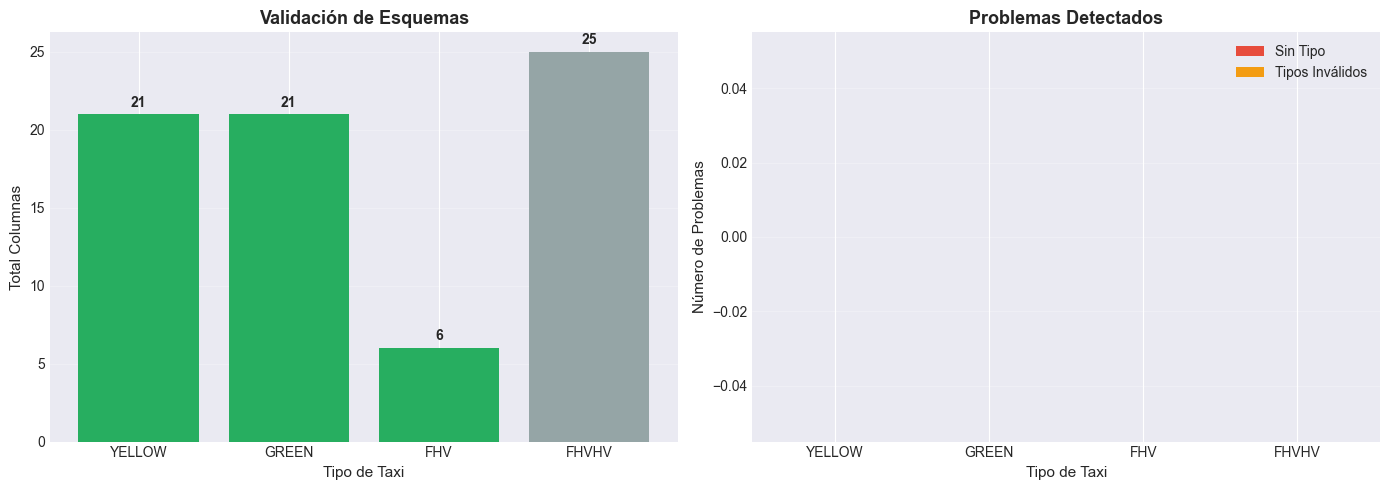


✅ VALIDACIÓN COMPLETADA:
   ✅ Todos los esquemas son válidos


In [21]:
# ============================================================
# 5. VALIDACIÓN DEL ESQUEMA UNIFICADO
# ============================================================

print("=" * 80)
print(" 5. VALIDACIÓN DEL ESQUEMA UNIFICADO")
print("=" * 80)

validation_results = []

for taxi_type, schema in ALL_SCHEMAS.items():
    is_excluded = taxi_type in EXCLUDED_TYPES
    
    # Verificar que todas las columnas tengan tipo definido
    missing_types = [col for col, dtype in schema.items() if not dtype or dtype == 'unknown']
    
    # Verificar duplicados
    columns = list(schema.keys())
    duplicates = len(columns) - len(set(columns))
    
    # Verificar tipos válidos
    valid_types = {'string', 'timestamp', 'double', 'float', 'decimal', 'bigint', 'int', 'smallint', 'tinyint', 'boolean'}
    invalid_types = []
    for dtype in schema.values():
        dtype_clean = dtype.lower().split('(')[0] if '(' in dtype else dtype.lower()
        if dtype_clean not in valid_types:
            invalid_types.append(dtype)
    
    validation_results.append({
        'Tipo': taxi_type.upper(),
        'Estado': 'EXCLUIDO' if is_excluded else 'ACTIVO',
        'Total Columnas': len(schema),
        'Sin Tipo': len(missing_types),
        'Duplicados': duplicates,
        'Tipos Inválidos': len(set(invalid_types))
    })

df_validation = pd.DataFrame(validation_results)

print("\n Validación de Esquemas:")
print(df_validation.to_string(index=False))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Estado de validación
ax1 = axes[0]
colors = [COLORS['excluded'] if row['Estado'] == 'EXCLUIDO' 
          else COLORS['success'] if row['Sin Tipo'] == 0 and row['Tipos Inválidos'] == 0
          else COLORS['warning'] if row['Sin Tipo'] < 5
          else COLORS['danger']
          for _, row in df_validation.iterrows()]

bars = ax1.bar(df_validation['Tipo'], df_validation['Total Columnas'], color=colors)
ax1.set_title('Validación de Esquemas', fontsize=13, fontweight='bold')
ax1.set_xlabel('Tipo de Taxi', fontsize=11)
ax1.set_ylabel('Total Columnas', fontsize=11)
ax1.grid(axis='y', alpha=0.25)

for bar, val in zip(bars, df_validation['Total Columnas']):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{int(val)}', ha='center', va='bottom', fontweight='bold')

# Gráfico 2: Problemas detectados
ax2 = axes[1]
x = np.arange(len(df_validation['Tipo']))
width = 0.35

bars1 = ax2.bar(x - width/2, df_validation['Sin Tipo'], width, 
                label='Sin Tipo', color=COLORS['danger'])
bars2 = ax2.bar(x + width/2, df_validation['Tipos Inválidos'], width,
                label='Tipos Inválidos', color=COLORS['warning'])

ax2.set_title('Problemas Detectados', fontsize=13, fontweight='bold')
ax2.set_xlabel('Tipo de Taxi', fontsize=11)
ax2.set_ylabel('Número de Problemas', fontsize=11)
ax2.set_xticks(x)
ax2.set_xticklabels(df_validation['Tipo'])
ax2.legend()
ax2.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

print("\n✅ VALIDACIÓN COMPLETADA:")
if df_validation['Sin Tipo'].sum() == 0 and df_validation['Tipos Inválidos'].sum() == 0:
    print("   ✅ Todos los esquemas son válidos")
else:
    if df_validation['Sin Tipo'].sum() > 0:
        print(f"   ⚠️ {df_validation['Sin Tipo'].sum()} columnas sin tipo definido")
    if df_validation['Tipos Inválidos'].sum() > 0:
        print(f"   ⚠️ {df_validation['Tipos Inválidos'].sum()} tipos inválidos detectados")

In [20]:
# ============================================================
# 6. RESUMEN EJECUTIVO FINAL
# ============================================================

print("=" * 80)
print(" 6. RESUMEN EJECUTIVO - ESQUEMAS UNIFICADOS")
print("=" * 80)

# Estadísticas globales
total_schemas = len(ALL_SCHEMAS)
total_columns = sum(len(s) for s in ALL_SCHEMAS.values())
active_schemas = {k: v for k, v in ALL_SCHEMAS.items() if k not in EXCLUDED_TYPES}
common_cols = []

if active_schemas:
    first_schema = list(active_schemas.values())[0]
    common_cols = [col for col in first_schema.keys() 
                   if all(col in s for s in active_schemas.values())]

print(f"\n ESTADÍSTICAS GLOBALES:")
print(f"   • Esquemas generados: {total_schemas}")
print(f"   • Total columnas: {total_columns}")
print(f"   • Promedio columnas por tipo: {total_columns/total_schemas:.1f}")
print(f"   • Columnas comunes entre tipos: {len(common_cols)}")

print(f"\n ESQUEMAS POR TIPO:")
for taxi_type, schema in ALL_SCHEMAS.items():
    is_excluded = taxi_type in EXCLUDED_TYPES
    status = " EXCLUIDO" if is_excluded else " ACTIVO"
    print(f"   • {taxi_type.upper()}: {len(schema)} columnas - {status}")

print(f"\n RECOMENDACIONES PARA BRONZE_TO_SILVER:")

if common_cols:
    print(f"    Usar {len(common_cols)} columnas comunes como base del esquema unificado")

# Identificar tipos con más columnas
if active_schemas:
    max_cols = max(active_schemas.values(), key=len)
    max_type = [k for k, v in active_schemas.items() if v == max_cols][0]
    print(f"    Usar {max_type.upper()} como referencia (más columnas: {len(max_cols)})")

# Tipos excluidos
excluded_types = [t for t in TAXI_TYPES if t in EXCLUDED_TYPES and t in ALL_SCHEMAS]
if excluded_types:
    print(f"\n TIPOS EXCLUIDOS:")
    for t in excluded_types:
        print(f"   • {t.upper()}: No se incluirá en el pipeline")

print(f"\n UBICACIÓN DE ARCHIVOS:")
print(f"   • Esquemas: {SCHEMAS_DIR}")
print("=" * 80)
print(" ANÁLISIS COMPLETADO")
print(f"   Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 80)

 6. RESUMEN EJECUTIVO - ESQUEMAS UNIFICADOS

 ESTADÍSTICAS GLOBALES:
   • Esquemas generados: 4
   • Total columnas: 73
   • Promedio columnas por tipo: 18.2
   • Columnas comunes entre tipos: 2

 ESQUEMAS POR TIPO:
   • YELLOW: 21 columnas -  ACTIVO
   • GREEN: 21 columnas -  ACTIVO
   • FHV: 6 columnas -  ACTIVO
   • FHVHV: 25 columnas -  EXCLUIDO

 RECOMENDACIONES PARA BRONZE_TO_SILVER:
    Usar 2 columnas comunes como base del esquema unificado
    Usar YELLOW como referencia (más columnas: 21)

 TIPOS EXCLUIDOS:
   • FHVHV: No se incluirá en el pipeline

 UBICACIÓN DE ARCHIVOS:
   • Esquemas: c:\Users\Jean Carlos\OneDrive\Desktop\BIG DATA FINAL\Final-Gesti-n_De_Datos_Masivos\data\silver\unified_schema\_schemas
 ANÁLISIS COMPLETADO
   Fecha: 2026-07-17 01:35:34
